In [1]:
# 1. Birthday Collisions [20 points]
#    [x] write p_shared(n), exact, using complement
#    [x] build P(365, n) with a loop
#    [x] print table of n and p_shared(n) for n = 5, 10..., 50
#    [x] round to 4 decimals

# Returns float: the probability of the collision of 2 people
#                sharing a birthday using a complement
def p_shared(n):
   DAYSINYEAR = 365
   permutation = 1  # Starting at 0 sets everything at 0 and returns undefined.
   # Does the permutation P(365, n). 
   for i in range(0, n):
      permutation = permutation * (DAYSINYEAR - i)
   return 1 - permutation / (DAYSINYEAR ** n)

# Prints a table of people starting at 5 and incrementing to 50 inclusively.
for i in range(5, 50 + 1, 5):
   print(f"p_shared({i}): {p_shared(i):.4f}")

p_shared(5): 0.0271
p_shared(10): 0.1169
p_shared(15): 0.2529
p_shared(20): 0.4114
p_shared(25): 0.5687
p_shared(30): 0.7063
p_shared(35): 0.8144
p_shared(40): 0.8912
p_shared(45): 0.9410
p_shared(50): 0.9704


### Problem 1A.) Birthday Collisions :

Use complement rule to find if at least 2 people share a birthday.
Pairs are intuitive, but we must find and state each one. Instead we can 
use permutations and product rule.

The provided formula Pshared(n) = 
   $1 - \frac{P(365, n)}{365^n}$

1 (the total probability of all outcomes) subtracted by 
  (the probability where everyone has a different birthday.)
= (the probability of at least 2 people sharing a birthday.)

Numerator P(365, n): uses permutation because we have different 
                     birthdays where order matters, with no repeats.
Denominator 365^n: we use product rule for denominator because 
                     each person, n, has 365 choices.

In [2]:
# 1b.) Threshold Probaiblity
#      [x] Print the smallest n with a probability greater than 0.50.
#      [x] Print the smallest n with a probability greater than 0.99.
#      [x] No hardcode

# Uses the formula to search for the smallest n where it goes above 0.5
# and the smallest n where it goes above 0.99.
n = 1
COLLISION_PROB_HALF = 0.5
COLLISION_PROB_NINETY_NINE = 0.99
# We search going up from n = 1 until we find the n 
# that passes the collision probability (0.5 and 0.99)
while p_shared(n) <= COLLISION_PROB_HALF:
   n += 1
   # print(f"p_shared({n}): {p_shared(n):.4f}") # test
lowest_n_half = n

n = 1
while p_shared(n) <= COLLISION_PROB_NINETY_NINE:
   n += 1
   # print(f"p_shared({n}): {p_shared(n):.4f}") # test
lowest_n_ninety_nine = n

print("Lowest n for 0.5:", lowest_n_half)
print(f"Value: {p_shared(lowest_n_half):.4f}")
print("Lowest n for 0.99:", lowest_n_ninety_nine)
print(f"Value: {p_shared(lowest_n_ninety_nine):.4f}")

Lowest n for 0.5: 23
Value: 0.5073
Lowest n for 0.99: 57
Value: 0.9901


### Problem 1B.) Threshold Probability 
How many people would it take to share a birthday, 
if the probability of collision to be 0.5?

Intuitively from our lecture slides it would about 180 people.

We find that it is at least 23 people to share a birthday.

How many people would it take to share a birthday,
if the probability of collision was 0.99 ?

We find that it is at least 57 people to share a birthday.
We learned from the pigeonhole principle that it takes 
366 to be 100% certain. So collisions can happen earlier.

Bounds and Probability for 60 people
------------------------------------------
Smallest n exceeding probability of 1: 28, 1.0356


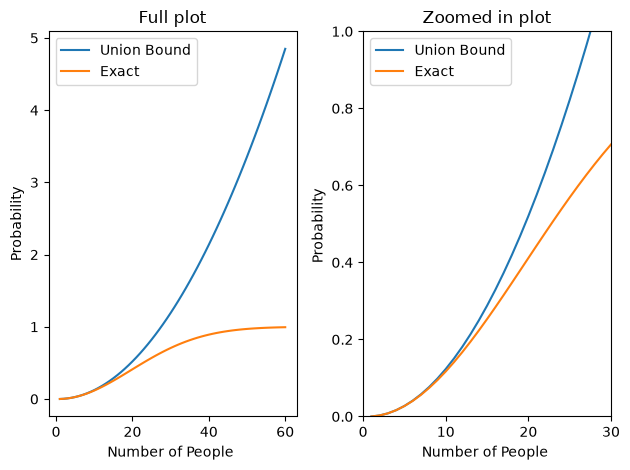

In [3]:
# 1c.) Union Bound
#      [x] Write union_bound(n) = C(n, 2) / 365
#      [x] Plot exact vs. bound for n = 1...60 on one figure
#      [x] Axis labels + Legend
#      [x] print smallest n where the bound is larger than 1

import matplotlib.pyplot as plt # W3 Schools
# print(plt.__version__) # confirm installation.

x_values = []           # the array of n or number of people 
y_values_exact = []     # the exact probability
y_values_bounds = []    # the probability of bounds
BOUND_LIMIT = 1      
BOUNDS = 60             # n people
smallest_n_bound = None # None sentinel to find smallest exceeding n of 1

# Computes and returns the union bound probability 
def union_bound(n):
   DAYS_IN_YEAR = 365
   orders_per_pair = 2 # (Jane, John), (John, Jane)
   # The total ordered pairs that are double counted (A, B), (B, A)
   ordered_pairs = (n * (n - 1))
   # We find the true number of pairs without the double count
   number_of_pairs = (ordered_pairs / orders_per_pair) 
   # Each pair has a probability 1 / 365 giving us the total.
   union_bound_probability = number_of_pairs / DAYS_IN_YEAR
   return union_bound_probability

# n = 23
# print(f"Bounds for {n} people , {union_bound(n):.4f}") # test

print(f"Bounds and Probability for {BOUNDS} people")
print(f"------------------------------------------")
# Iterate through the amount of people and assign them to x and y values.
for i in range (1, BOUNDS + 1):
   # Compute results
   result = union_bound(i)
   x_values.append(i)   
   y_values_bounds.append(result)
   y_values_exact.append(p_shared(i))

   # print(f"Bound:    {i}: {result:.4f}") # test
   # print(f"p_shared: {i}: {p_shared(i):.4f}\n") # test
   
   if result > BOUND_LIMIT and smallest_n_bound is None:
      smallest_n_bound = i  # save once to print later.
      smallest_n_result = result
         
print("Smallest n exceeding probability of 1: " 
      f"{smallest_n_bound}, {smallest_n_result:.4f}")

# plt.plot(xpoints, ypoints) (W3 schools)
# A figure that splits the full plot into one half and a zoomed plot on the right
fig, (full_plot, zoom_plot) = plt.subplots(1 , 2)
full_plot.set_title("Full plot")
full_plot.set_xlabel("Number of People ")
full_plot.set_ylabel("Probability")
full_plot.plot(x_values, y_values_bounds, label = "Union Bound")
full_plot.plot(x_values, y_values_exact, label = "Exact")
full_plot.legend()

zoom_plot.set_title("Zoomed in plot")
zoom_plot.set_xlabel("Number of People ")
zoom_plot.set_ylabel("Probability ")
# We limit what the right graph shows
zoom_plot.set_ylim(0, 1)
zoom_plot.set_xlim(0, 30)
zoom_plot.plot(x_values, y_values_bounds, label = "Union Bound")
zoom_plot.plot(x_values, y_values_exact, label = "Exact")
zoom_plot.legend()
fig.tight_layout() # so that probability doesn't over lap with left figure
plt.show()

### Problem 1C.) Union bound 
The union bound is the most the probability could be, based on the n amount of people where at least 2 share a birthday.

The formula we use and provided:
$p_{shared}(n) \le \binom{n}{2}/365$

The n that stays close to the exact answer would be n, 1 - 12, and a large n is useless, as probability cannot go above 1 so that's why we found the smallest n that exceeds it at n = 28 (above)

The exact answer will always be less than or equal to the union bound as 
it overcounts the outcomes where more than one pair shares a birthday. 



In [4]:
# Problem 2A.) Counting Lattice Paths (Taken from assignment PDF)
#              [x] write paths_enumerate
#              [x] print table 1 <= m, n <= 6 
#              [x] confirm paths_enumereate(3, 7)

# Counts and generates the paths with recursion  
MAX_SIZE = 6
def paths_enumerate(m, n): # m being rows, n being columns
   def paths_from(r, c):   # r, c where the robot is standing
      # Check if robot is at the finish (m - 1, n - 1)
      if r == m - 1 and c == n - 1:
         return 1

      # Check if robot is off the grid based on column
      if c > n - 1:  # n - 1 is last column
         return 0

      # Check if robot is off the grid based on row
      if r > m - 1:
         return 0
      # every path goes down or right first.
      return paths_from(r + 1, c) + paths_from(r, c + 1) 
   return paths_from(0, 0)

for rows in range(1, MAX_SIZE  + 1) : # 1 - 6 inclusive
   for cols in range(1, MAX_SIZE + 1):
      print(f"{paths_enumerate(rows, cols):5}", end="")
   print()

# Initial tests
# print("Expected: 1 ")
# print(f"Actual: {paths_enumerate(1,1)}") 
# print("Expected: 2 ")
# print(f"Actual: {paths_enumerate(2,2)}")
# print("Expected: 3 ")
# print(f"Actual: {paths_enumerate(2,3)}") 
print("Confirm paths_enumerate(3,7) == 28")
print("Expected: 28 ")
print(f"Actual: {paths_enumerate(3,7)}") 



    1    1    1    1    1    1
    1    2    3    4    5    6
    1    3    6   10   15   21
    1    4   10   20   35   56
    1    5   15   35   70  126
    1    6   21   56  126  252
Confirm paths_enumerate(3,7) == 28
Expected: 28 
Actual: 28


### Problem 2A.) Counting Lattice paths
Since the robot walks every path separately, and  it returns 1 at the finish for each one, the running time grows with the number of paths, almost exponentioally by the way we can see the diagonal 6 to 20 to 70.

In [5]:
# Problem 2B.) Paths by formula 
#  Taken from assignment PDF
#              [x] Write paths_formula(m, n) = C(m + n - 2, m - 1)
#              [x] write factorial(k), 
#              [x] n_choose_k from factorial, no math.comb
#              [x] print PASS/FAIL: if two functions agree on every grid
#              [x] print paths_formula(18, 18)

# Recursively determines the factorial of a given number 4! 4 x 3 x 2 x 1.
def factorial(k):
   if k < 2:
      return 1
   else:
      return k * factorial(k - 1)
# print("Testing Factorial...")
# print(f"Expected: 120, Actual: {factorial(5)}")

# Determines binomial coefficient or combinatoin
def n_choose_k(n, k):
   numerator = factorial(n)
   denominator = factorial(k) * factorial(n - k)
   return (numerator // denominator) 
# print("Testing n_choose_k...")
# print(f"Expected : 6, Actual: {n_choose_k(4, 2)}")

# Determines 
def paths_formula(m, n): 
   total = m + n - 2 # total number of moves
   k = m - 1         # how many moves go down
   combination = n_choose_k(total, k)
   return combination

is_valid = True # Assume flag is true for now
# Iterate through the grid and determine if functions agree
for rows in range(1, MAX_SIZE + 1) : # 1 - 6 inclusive
   for cols in range(1, MAX_SIZE + 1):
      # A mismatch on any grid sets is_valid to FAIL
      if paths_formula(rows, cols) != paths_enumerate(rows, cols):
         is_valid = False

print("Do functions agree on every grid?")
print("PASS" if is_valid else "FAIL")

print(f"paths_formula(18, 18): {paths_formula(18, 18)}")

Do functions agree on every grid?
PASS
paths_formula(18, 18): 2333606220


### Problem 2B.) Countting Lattice Paths by Formula
paths_formula uses a combination, choose which of the m + n - 2 moves are down. While the number is fine. The method of part(a) is too slow. We are able to compute the total paths directly because of the formulas, with factorials but part(a) walks those 
paths separately making too slow to be used practically. 

In [6]:
# Problem 2C.) One Blocked Cell and the complement rule
#  Taken from assignment PDF
#  [x] paths_through(m, n, r, c) as a product of two binomial
#  [x] paths_avoiding(m, n, r, c) with the complement rule 
#  [x] verify paths_avoiding vs. enumeration that never enters the blocked cell
#     all grids 1 <= m, n <= 6 and every cell PASS/FAIL
#  [x] 7 x 7 grid: P(path visits (3,3)) as exact fraction and as a decimal
from fractions import Fraction  # keeps the probability as an exact fraction

# Counts the paths that go through cell (r, c)
def paths_through(m, n, r, c):
   # start at (0, 0) to (r, c) is a (r + 1) x (c + 1) grid
   paths_to_cell = paths_formula(r + 1, c + 1)
   # (r, c) to the finish is whatever is left, a (m - r) x (n - c) grid
   paths_from_cell = paths_formula(m - r, n - c)
   # product rule, any way in can pair with any way out
   return paths_to_cell * paths_from_cell 

# We avoid the paths by getting the total and subtracting all the paths that go through.
def paths_avoiding(m, n, r, c):
   return paths_formula(m, n) - paths_through(m, n, r, c)

# Same walk as 2A, but now some cells are walls the robot can't step on.
# blocked is a list of (row, col) cells, so 2D can reuse this with 2 cells
def paths_enumerate_blocked(m, n, blocked):
   def paths_from(r, c):
      # walked off the grid, dead end
      if r > m - 1 or c > n - 1:
         return 0
      # stepped on a blocked cell, dead end
      if (r, c) in blocked:
         return 0
      # made it to the finish, that's 1 path
      if r == m - 1 and c == n - 1:
         return 1
      # every path goes down or right first
      return paths_from(r + 1, c) + paths_from(r, c + 1)
   return paths_from(0, 0)

# Small tests on a 3 x 3 grid with the middle (1, 1) blocked
print("Small tests")
print(f"paths_through(3, 3, 1, 1)  Expected: 4, Actual: {paths_through(3, 3, 1, 1)}")
print(f"paths_avoiding(3, 3, 1, 1) Expected: 2, Actual: {paths_avoiding(3, 3, 1, 1)}")
print(f"paths_enumerate_blocked(3, 3, [(1, 1)]) Expected: 2, "
      f"Actual: {paths_enumerate_blocked(3, 3, [(1, 1)])}")
print(f"paths_through(3, 3, 0, 0)  Expected: 6, Actual: {paths_through(3, 3, 0, 0)}")  # every path starts here
print()

# Check every grid 1 <= m, n <= 6 and block every cell one at a time
is_valid = True # stays True only if every grid and cell matches
for rows in range(1, MAX_SIZE + 1):
   for cols in range(1, MAX_SIZE + 1):
      for r in range(rows):        # every row in this grid 0 ... rows - 1
         for c in range(cols):     # every column in this grid 0 ... cols - 1
            # A mismatch on any grid/cell sets is_valid to FAIL
            if paths_avoiding(rows, cols, r, c) != paths_enumerate_blocked(rows, cols, [(r, c)]):
               is_valid = False

print("Does paths_avoiding match enumeration on every grid and every cell?")
print("PASS" if is_valid else "FAIL")
print()

# 7 x 7 grid, chance a random path goes through (3, 3)
GRID = 7
paths_visiting = paths_through(GRID, GRID, 3, 3)
total_paths = paths_formula(GRID, GRID)
prob_visit = Fraction(paths_visiting, total_paths)  # reduces automatically
print(f"7 x 7 grid: {paths_visiting} of {total_paths} paths visit (3, 3)")
print(f"P(visits (3, 3)) exact fraction: {prob_visit}")
print(f"P(visits (3, 3)) decimal:{float(prob_visit):.4f}")

Small tests
paths_through(3, 3, 1, 1)  Expected: 4, Actual: 4
paths_avoiding(3, 3, 1, 1) Expected: 2, Actual: 2
paths_enumerate_blocked(3, 3, [(1, 1)]) Expected: 2, Actual: 2
paths_through(3, 3, 0, 0)  Expected: 6, Actual: 6

Does paths_avoiding match enumeration on every grid and every cell?
PASS

7 x 7 grid: 400 of 924 paths visit (3, 3)
P(visits (3, 3)) exact fraction: 100/231
P(visits (3, 3)) decimal:0.4329


### Problem 2C.) One Blocked Cell and the Complement Rule
We use the product rule at paths_through because every way of getting to the cell can pair with every way from the cell to the finish.
$$\text{paths through }(r,c) = \binom{r+c}{r} \cdot \binom{(m-1-r)+(n-1-c)}{m-1-r}$$


The complement rule applies to finding the paths avoided by subtracting
the paths through from the total paths to get our avoided paths.

The PASS or FAIL shows us the formula count matches the brute force way of enumeration so we know that our formula and enumeration work as intended.

For a random path on a 7 x7 we have paths through / total paths = the fraction above so about 43 percent cross the center.

In [7]:
# Problem 2D.) Two blocked cell and inclusion - exclusion
#  [x] paths_avoiding_two(m, n, a, b)
#  [x] 7 x 7 grid values for a = (2, 3), b = (4, 1) and a = (1, 2), b = (3, 4)
#  [x] Check both against enumeration

# Counts paths that hit BOTH cells a and b |A and B|
def paths_through_both(m, n, a, b):
   # sort so "first" is the cell the robot would reach first, smaller row first
   first, second = sorted([a, b])
   r1, c1 = first
   r2, c2 = second
   # robot only goes down and right, so if second is LEFT of first it can't hit both
   if c2 < c1:
      return 0
   # three pieces: start -> first, first -> second, second -> finish
   start_to_first = paths_formula(r1 + 1, c1 + 1)
   first_to_second = paths_formula(r2 - r1 + 1, c2 - c1 + 1)
   second_to_finish = paths_formula(m - r2, n - c2)
   # product rule again, just with 3 pieces this time
   return start_to_first * first_to_second * second_to_finish

# Inclusion-exclusion: |A or B| = |A| + |B| - |A and B|, then the complement rule
def paths_avoiding_two(m, n, a, b):
   hits_a = paths_through(m, n, a[0], a[1])    # |A|
   hits_b = paths_through(m, n, b[0], b[1])    # |B|
   hits_both = paths_through_both(m, n, a, b)  # |A and B|, counted twice so subtract once
   hits_either = hits_a + hits_b - hits_both   # |A or B|
   return paths_formula(m, n) - hits_either    # everything that dodges both

# The two pairs the PDF asks for on the 7 x 7 grid
pairs = [((2, 3), (4, 1)), ((1, 2), (3, 4))]
for a, b in pairs:
   formula_count = paths_avoiding_two(GRID, GRID, a, b)
   enum_count = paths_enumerate_blocked(GRID, GRID, [a, b])
   both_count = paths_through_both(GRID, GRID, a, b)
   print(f"a = {a}, b = {b}")
   print(f" |A and B| = {both_count}")
   print(f" avoiding both, formula:     {formula_count}")
   print(f" avoiding both, enumeration: {enum_count}")
   print("  PASS" if formula_count == enum_count else "   FAIL")

a = (2, 3), b = (4, 1)
 |A and B| = 0
 avoiding both, formula:     469
 avoiding both, enumeration: 469
  PASS
a = (1, 2), b = (3, 4)
 |A and B| = 180
 avoiding both, formula:     376
 avoiding both, enumeration: 376
  PASS


### Problem 2D.) Two Blocked Cells and Inclusion-Exclusions
|A ∩ B| is a product of three binomials when one cell is down-and-right of the other. For example, a = (1, 2), b = (3, 4). Then a path can hit both in three places, start to one cell, that one cell to the second, and that second cell to the finish. Each is a binomial and we can use the product rule to multiply them.

When one cell is below but to the left of the other. That is when |A ∩ B| = 0.
For example from the pdf, a  = (2, 3), b = (4, 1)
If we reach the second after the first cell that would mean moving left or up and that is not allowed.

We subtract |A ∩ B| because those paths were counted in both |A| and |B|.


In [8]:
# Problem 3A.) A Naive Bayes spam filter from scratch:
#  [x] load spam.csv with latin-1, ignore the empty columns
#  [x] lowercase each message and split it into word tokens
#  [x] shuffle with a fixed seed, 80% training / 20% test
#  [x] print number of training/test messages and spam in each
import csv     # built in, reads the csv for us (pandas isn't installed in .venv)
import random
import re      # regular expressions, used to pull words out of a message

# Lowercase the message and grab runs of letters and numbers, FREE!! is free
def tokenize(message):
   return re.findall(r"[a-z0-9]+", message.lower())

# Each message becomes label, list of words
messages = []
# my spam.csv sits one folder up in lab 2
with open("../spam.csv", encoding="latin-1", newline="") as file:
   reader = csv.reader(file)
   next(reader)                    # skip the header row (v1, v2, ...)
   for row in reader:
      label = row[0]               # first column is ham / spam
      text = row[1]                # second column is the message, the rest are empty
      messages.append((label, tokenize(text)))

# Shuffle with a fixed seed so the split comes out the same every run
SEED = 42
rng = random.Random(SEED)
rng.shuffle(messages)

# First 80% train, last 20% test
split_at = int(0.8 * len(messages))
train = messages[:split_at]
test = messages[split_at:]

# Counts how many messages in a list are spam
def count_spam(data):
   spam_count = 0
   for label, tokens in data:
      if label == "spam":
         spam_count += 1
   return spam_count

print(f"Training messages: {len(train)}, spam in training: {count_spam(train)}")
print(f"Test messages:     {len(test)}, spam in test:     {count_spam(test)}")
print()


Training messages: 4457, spam in training: 589
Test messages:     1115, spam in test:     158



### Problem 3A.) Loading and Splitting the Data
We lowercase everything and keep only the letters and numbers so capital words are the same as lowercase words. 
We shuffle with a fixed seed (42) so the split is the same every time it runs. 
We shuffle so the test set is a random sample.

In [9]:
# Problem 3B.) Train Naive Bayes by hand (training set ONLY)
#  [x] priors P(ham), P(spam)
#  [x] word likelihoods with Laplace add-one smoothing
#  [x] classify with log P(c) + sum of log P(w | c)
#  [x] print the two priors and the vocabulary size
import math
from collections import Counter  # a dict that counts things for us

CLASSES = ["ham", "spam"]

# Priors: what fraction of the training messages are ham or spam
class_counts = Counter()
for label, tokens in train:
   class_counts[label] += 1

priors = {}
for label in CLASSES:
   priors[label] = class_counts[label] / len(train)

# Count every word in each class, and build the vocab from training only
word_counts = {"ham": Counter(), "spam": Counter()}
vocab = set()                        # set so each word only shows up once
for label, tokens in train:
   word_counts[label].update(tokens) # adds 1 for every word in the message
   vocab.update(tokens)

total_words = {}
for label in CLASSES:
   total_words[label] = sum(word_counts[label].values())

V = len(vocab)  # |V|

# Laplace add-one: P(w | c) = (count(w, c) + 1) / (total_words(c) + |V|)
# the + 1 means a word we never saw in a class doesn't make the whole thing 0
def likelihood(word, label):
   return (word_counts[label][word] + 1) / (total_words[label] + V)

# Score each class with logs and pick the bigger one
def classify(tokens):
   best_label = None   # None sentinel again, like 1C
   best_score = None
   for label in CLASSES:
      score = math.log(priors[label])
      for word in tokens:
         # words that never showed up in training aren't in |V|, so we skip them
         if word in vocab:
            score += math.log(likelihood(word, label))
      if best_score is None or score > best_score:
         best_label = label
         best_score = score
   return best_label

print(f"P(ham)  = {priors['ham']:.4f}")
print(f"P(spam) = {priors['spam']:.4f}")
print(f"Vocabulary size |V| = {V}")
print()

# Small tests
print("Small tests")
print(f"P(ham) + P(spam)  Expected: 1.0, Actual: {priors['ham'] + priors['spam']:.4f}")
# smoothed likelihoods for one class should still add up to 1 over the vocab
spam_total = sum(likelihood(word, "spam") for word in vocab)
print(f"sum of P(w | spam) over vocab  Expected: 1.0, Actual: {spam_total:.4f}")  

P(ham)  = 0.8678
P(spam) = 0.1322
Vocabulary size |V| = 7658

Small tests
P(ham) + P(spam)  Expected: 1.0, Actual: 1.0000
sum of P(w | spam) over vocab  Expected: 1.0, Actual: 1.0000


### Problem 3B.) Naive Bayes from Scratch
The priors are the fraction of training messages in each class before looking 
at the words. From the results, we know most texts are ham based on the priors.

P(w|c) is the likelihood how often word w shows up in class c, out of all the words in that 
class.

If the code never sees a test word in the training and is not trained for it then
the code will skip it and does not change the score.

In [10]:
# Problem 3C.) Test the filter
#  [x] confusion counts on the test set
#  [x] accuracy, precision and recall for spam

# spam is the "positive" class, so a caught spam is a true positive
tp = 0  # said spam, really spam (caught it)
fp = 0  # said spam, really ham (real text thrown in spam folder)
tn = 0  # said ham, really ham (real text let through)
fn = 0  # said ham, really spam (spam slipped through)
for label, tokens in test:
   predicted = classify(tokens)
   if predicted == "spam" and label == "spam":
      tp += 1
   elif predicted == "spam" and label == "ham":
      fp += 1
   elif predicted == "ham" and label == "ham":
      tn += 1
   else:
      fn += 1

accuracy = (tp + tn) / len(test)  # how many it got right overall
precision = tp / (tp + fp)        # of the ones it called spam, how many really were
recall = tp / (tp + fn)           # of the real spam, how many it caught

print("Confusion counts (spam = positive)")
print("                predicted ham   predicted spam")
print(f"actual ham   {tn:15}   {fp:14}")
print(f"actual spam  {fn:15}   {tp:14}")
print()
print(f"Accuracy:         {accuracy:.4f}")
print(f"Precision (spam): {precision:.4f}")
print(f"Recall (spam):    {recall:.4f}")
print()
# Small test: every test message lands in exactly one box
print(f"tp + fp + tn + fn  Expected: {len(test)}, Actual: {tp + fp + tn + fn}")

Confusion counts (spam = positive)
                predicted ham   predicted spam
actual ham               949                8
actual spam               16              142

Accuracy:         0.9785
Precision (spam): 0.9467
Recall (spam):    0.8987

tp + fp + tn + fn  Expected: 1115, Actual: 1115


### Problem 3C.) Evaluating the Spam Filter
$$P(\text{spam} \mid \text{msg}) = \frac{P(\text{msg} \mid \text{spam}) \, P(\text{spam})}{P(\text{msg})}$$

i. P(spam), the chance a message is spam before reading it. 
The likelihood of P(msg|spam), of how likely these words are spam. 
We treat these words as independent so it's the product of P(w | spam)
P(msg) is the evidence of the overall change of seeing this message.
The evidence can be dropped because ham and spam have the same denominator so
by dividing both by the same number it does not change the winner when comparing
which class scores higher. 

ii. The classifier adds logarithms because each P(w|c) is a tiny number. 
Multiplying dozens of them gets the really small so the computer has to round it 
to 0. This causes both classes to tie at 0. By doing logs we can turn them into
reasonable numbers so it does not round and whichever class was bigger is 
bigger.

iii. I think would rather see recall for spam because I would not mind a message getting hidden if that were to protect my main inbox from phishing or bad links, because at one point my school inbox had spam coming through more than actual canvas notifications or school.